In [6]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
import time
import sympy as sp

In [7]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [8]:

def hk_integrate(pham,sim_time,num_data_points):
    #H_num = pham.H.subs(dict(pham.H_params))
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                   if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols 
               if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2', 
                                  'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                  'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    
    rho1,rho2,sigma1,sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    #H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1,lam2 = se.symbols('lambda1 lambda2')
    Lam1,Lam2 = se.symbols('Lambda1 Lambda2')
    eta1,eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating  ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)

    deta1_dt  = se.diff(H_planar, kap1)
    dkap1_dt  =  -se.diff(H_planar, eta1)
    deta2_dt  = se.diff(H_planar, kap2)
    dkap2_dt  =  -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
    func = se.Lambdify(vars_list,H_planar)

    jup = pham.state.particles[1]
    sat = pham.state.particles[2]

    initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,jup.eta, jup.kappa, sat.eta, sat.kappa]
    derivs_at_0 = func(*initial_conditions)

    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    eqs_hy = [hy.from_sympy(sp.sympify(eq), {sp.Symbol('lambda1'): lam1_hy, 
                                          sp.Symbol('Lambda1'): Lam1_hy,
                                          sp.Symbol('lambda2'): lam2_hy, 
                                          sp.Symbol('Lambda2'): Lam2_hy,
                                          sp.Symbol('eta1'): eta1_hy, 
                                          sp.Symbol('kappa1'): kap1_hy,
                                          sp.Symbol('eta2'): eta2_hy, 
                                          sp.Symbol('kappa2'): kap2_hy})
           for eq in derivs]

    ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-16)

    e_i = float(func(*ta.state))
    print(e_i)

    times = np.linspace(0,sim_time,int(num_data_points))*2*np.pi 
    e_sat = np.zeros(len(times))
    pomega_sat = np.zeros(len(times))
    e_j = np.zeros(len(times))
    pomega_j = np.zeros(len(times)) 
    a_sat = np.zeros(len(times))

    def get_sma(Lambda, m, M=1.0):
        return (Lambda / m) ** 2



    start = time.perf_counter()
    print('*** Starting Simulation ***')
    '''res, min_dt, max_dt, num_steps, callback, flat_states = ta.propagate_grid(times.tolist(), max_delta_t=0.01)

    flat_states = np.array(flat_states)

    num_vars = 8 
    state_matrix = flat_states.reshape(-1, num_vars)

    L_all   = state_matrix[:, 3]
    eta_all = state_matrix[:, 6]
    kap_all = state_matrix[:, 7]

    e_sat = get_ecc(kap_all, eta_all, L_all)
    pomega_sat = get_pomega(kap_all, eta_all)'''
    
    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i],max_delta_t=float(10))
        L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
        Lj, etaj, kapj = ta.state[1], ta.state[4], ta.state[5]
        e_sat[i] = get_ecc(kap, eta, L)
        pomega_sat[i] = get_pomega(kap, eta)
        e_j[i] = get_ecc(kapj, etaj, Lj)
        pomega_j = get_pomega(kapj, etaj)
        sat_particle = pham.state.particles[2]
        a_sat[i] = (L / sat_particle.m) ** 2

        
    end = time.perf_counter()

    e_f = float(func(*ta.state))
    print(e_f)
    e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
    print(f'Energy Percent Change: {e_per} %')
    
    print('*** Simulation Complete ***')

    print('Time elapsed  = ' + str(end-start) + ' seconds')

    return times, pomega_sat, e_sat, a_sat

In [ ]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e7, 1e5)

Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 3rd Order 2:1')

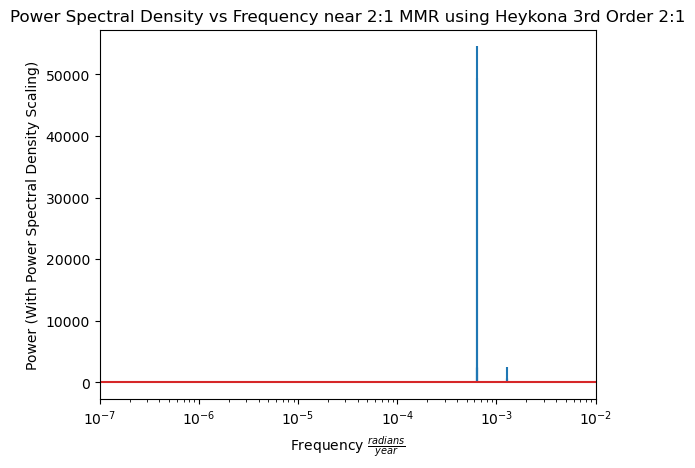

In [6]:
f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 3rd Order 2:1')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166636107952e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [01:39<00:00, 1008.11it/s]


-8.880166636104948e-05
Energy Percent Change: 3.383489740252582e-11 %
*** Simulation Complete ***
Time elapsed  = 90.38609662399904 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 3rd Order 2:1')

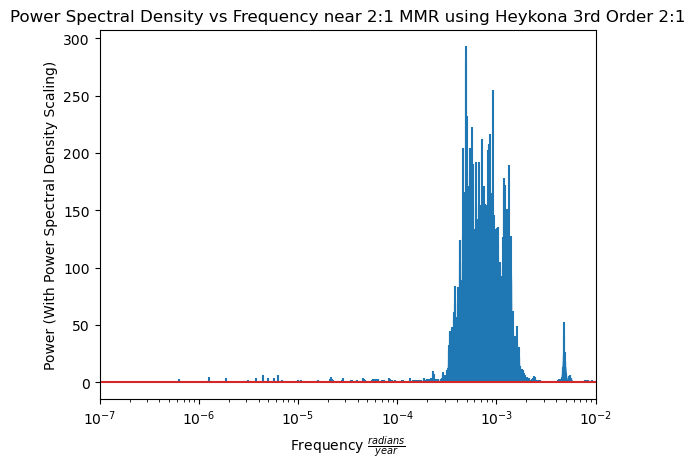

In [7]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e7, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 3rd Order 2:1')

In [ ]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e7, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 2nd Order 2:1')

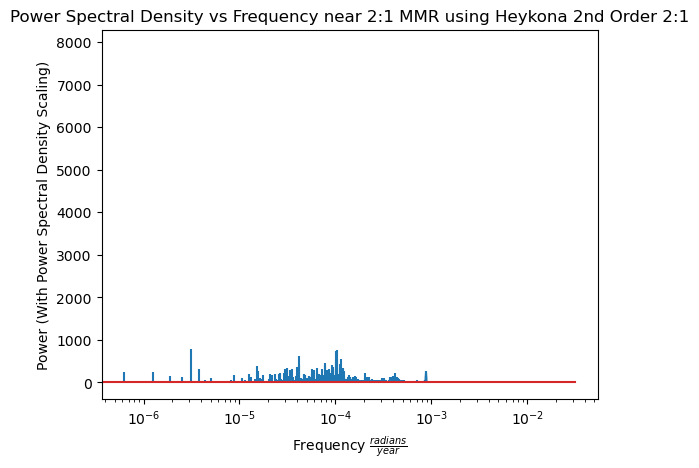

In [9]:
plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 2nd Order 2:1')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663609939e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:35<00:00, 2828.09it/s]


-8.880166636101256e-05
Energy Percent Change: 2.1015179848138466e-11 %
*** Simulation Complete ***
Time elapsed  = 33.60943765400043 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 2nd Order 2:1')

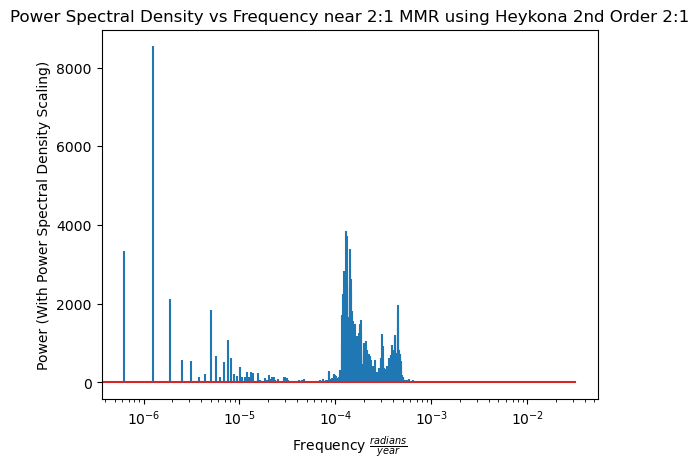

In [9]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e7, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 2nd Order 2:1')

Initial Energy: -8.880166636099383e-05


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [01:55<00:00, 864.47it/s]


Final Energy: -8.880166636098633e-05
Energy Percent Change: 8.43964738999316e-12 %


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 2nd Order 2:1')

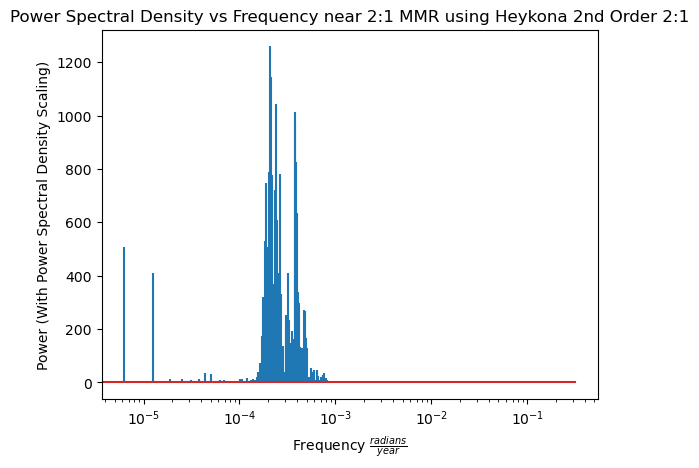

In [11]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1) 

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    a_sat[i] = pham.state.particles[2].a
    e_sat[i] = pham.state.particles[2].e
    long_peri_sat[i] = pham.state.particles[2].pomega

e_f = pham.calculate_energy()
print('Final Energy: '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')

f_hy,pxx_hy = pomega_ft(times, long_peri_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heykona 2nd Order 2:1')

In [ ]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
e_sat_test_particle = np.zeros(len(times))
sat_p = np.zeros(len(times))
j_p = np.zeros(len(times))
H_energy = np.zeros(len(times))
a_sat_test_particle = np.zeros(len(times))
sat_pomega = np.zeros(len(times))

sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    e_sat_test_particle[i] = sim.particles[2].e
    a_sat_test_particle[i] = sim.particles[2].a
    sat_p[i] = sim.particles[2].P
    j_p[i] = sim.particles[1].P
    sat_pomega[i] = sim.particles[2].pomega
    H_energy[i] = sim.energy()
    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))

In [16]:
print('Final Megno value: ' + str(sim.megno()))

Final Megno value: 2.0000263506182807


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Rebound')

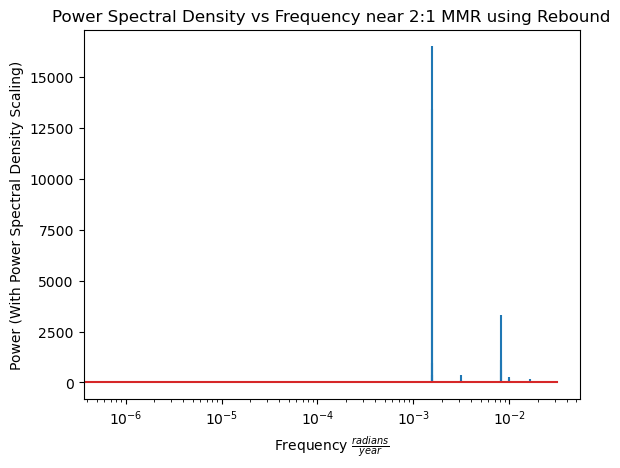

In [17]:
f,pxx = pomega_ft(times, sat_pomega, e_sat_test_particle)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Rebound')

Initial Energy: -8.880166636745833e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x77f0ae8a56e0, [0.0, 0.0, 0.0023481950905446173]>


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [03:20<00:00, 499.73it/s]


Final Energy: -8.880166636746212e-05
Energy Percent Change: 4.273239184495584e-12 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x77f091b97890, [0.0, 0.0, 0.002348195090544571]>


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Rebound')

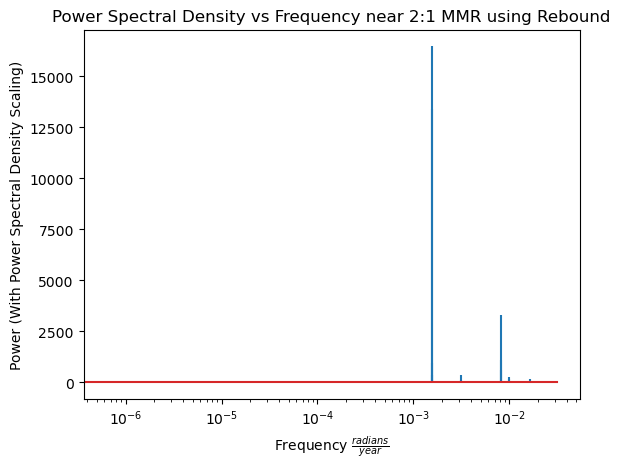

In [14]:
sim = rebound.Simulation()
sim.integrator = "ias15"
#sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
e_sat_test_particle = np.zeros(len(times))
sat_p = np.zeros(len(times))
j_p = np.zeros(len(times))
H_energy = np.zeros(len(times))
a_sat_test_particle = np.zeros(len(times))
sat_pomega = np.zeros(len(times))

#sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    e_sat_test_particle[i] = sim.particles[2].e
    a_sat_test_particle[i] = sim.particles[2].a
    sat_p[i] = sim.particles[2].P
    j_p[i] = sim.particles[1].P
    sat_pomega[i] = sim.particles[2].pomega
    H_energy[i] = sim.energy()
    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))

f,pxx = pomega_ft(times, sat_pomega, e_sat_test_particle)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Rebound')

In [ ]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(5e3))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=6)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=5) 

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 1e7, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka 5th Order 2:1')

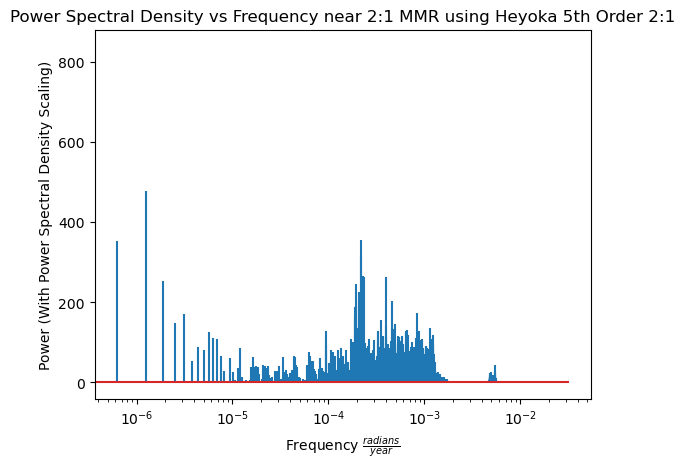

In [19]:
plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka 5th Order 2:1')